# Clipping (Hard & Soft)

Both clipping functions apply a **nonlinear transfer curve** that limits the output amplitude, introducing harmonic distortion. The character of the distortion depends on how abruptly the limiting occurs.

| Function | Description |
| --- | --- |
| `hard_clip` | Clip signal symmetrically to `[−threshold, threshold]`. Abrupt onset of limiting — creates strong, high-order odd harmonics and a discontinuity in the derivative. Models overdriven transistors or op-amps hitting the power rail. |
| `soft_clip` | Tanh saturation with adjustable `drive`: `y = tanh(drive · x) / tanh(drive)`. Smooth, asymptotically bounded — output stays in `(−1, 1)` for all inputs. Dominant 3rd harmonic; models tube triode compression. |


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from python.generators import generate_sine
from python.nonlinear import hard_clip, soft_clip

FS = 44100

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## Visualisation

Transfer curves, clipped waveforms, and harmonic spectra for both clipping types applied to a 440 Hz sine.

**2 × 3 grid:**

**Top row — hard_clip, three thresholds (1.0 / 0.7 / 0.4):**
- **Transfer curve:** piecewise-linear; kink at ±threshold; above threshold the output is flat
- **Waveform:** sine tops are progressively flattened as threshold decreases; lower threshold = more clipping
- **Spectrum:** strong odd harmonics (3rd, 5th, 7th, …) appear; **high-order** harmonics grow with severity of clipping because the transfer curve has a sharp corner

**Bottom row — soft_clip (tanh), three drive values (1 / 3 / 8):**
- **Transfer curve:** smooth S-curve; no discontinuity; output asymptotically approaches ±1
- **Waveform:** rounded peaks with no flat top; the transition from linear to limited is gradual
- **Spectrum:** dominated by the **3rd harmonic**; higher harmonics roll off rapidly — gives a "warm" distortion character compared to hard clipping

Hard clipping is used in digital fuzz/distortion pedals; soft clipping is preferred in tube-amp emulation for its smoother distortion character.


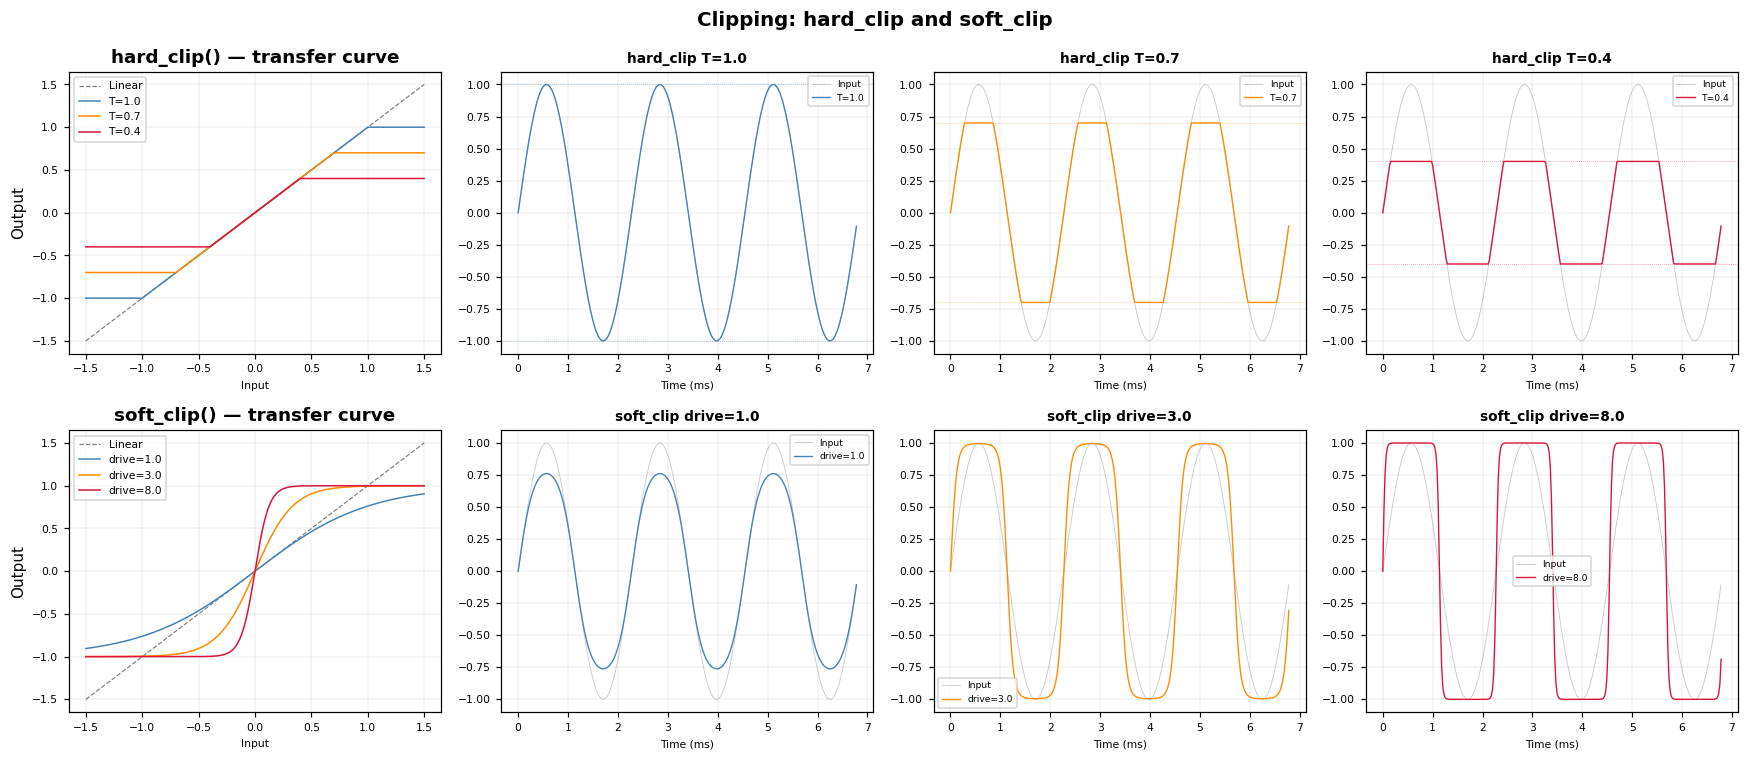

In [2]:
FS = 44100
FREQ = 440.0
DURATION = 3 / FREQ

_, sig = generate_sine(freq=FREQ, fs=FS, duration=DURATION)
t_ms = np.arange(len(sig)) / FS * 1000
x_tc = np.linspace(-1.5, 1.5, 500)


def _spectrum_db(s: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    freqs = np.fft.rfftfreq(len(s), d=1.0 / FS)
    db = 20 * np.log10(np.abs(np.fft.rfft(s)) + 1e-12)
    return freqs, db


COLORS = ["steelblue", "darkorange", "crimson"]
CLIP_THRESHOLDS = [1.0, 0.7, 0.4]
DRIVES = [1.0, 3.0, 8.0]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

# Transfer curves
ax = axes[0, 0]
ax.plot(x_tc, x_tc, color="gray", linewidth=0.8, linestyle="--", label="Linear")
for thresh, color in zip(CLIP_THRESHOLDS, COLORS):
    ax.plot(x_tc, hard_clip(x_tc, threshold=thresh), color=color, linewidth=1.0, label=f"T={thresh}")
ax.set_title("hard_clip() — transfer curve", fontweight="bold")
ax.set_xlabel("Input")
ax.set_ylabel("Output")
ax.legend(fontsize=7)

ax = axes[1, 0]
ax.plot(x_tc, x_tc, color="gray", linewidth=0.8, linestyle="--", label="Linear")
for drive, color in zip(DRIVES, COLORS):
    ax.plot(x_tc, soft_clip(x_tc, drive=drive), color=color, linewidth=1.0, label=f"drive={drive}")
ax.set_title("soft_clip() — transfer curve", fontweight="bold")
ax.set_xlabel("Input")
ax.set_ylabel("Output")
ax.legend(fontsize=7)

# Waveforms
for col, (thresh, color) in enumerate(zip(CLIP_THRESHOLDS, COLORS), start=1):
    out = hard_clip(sig, threshold=thresh)
    axes[0, col].plot(t_ms, sig, color="gray", linewidth=0.6, alpha=0.4, label="Input")
    axes[0, col].plot(t_ms, out, color=color, linewidth=0.9, label=f"T={thresh}")
    axes[0, col].axhline(thresh, color=color, linewidth=0.5, linestyle=":", alpha=0.6)
    axes[0, col].axhline(-thresh, color=color, linewidth=0.5, linestyle=":", alpha=0.6)
    axes[0, col].set_title(f"hard_clip T={thresh}", fontsize=9, fontweight="bold")
    axes[0, col].legend(fontsize=6)

for col, (drive, color) in enumerate(zip(DRIVES, COLORS), start=1):
    out = soft_clip(sig, drive=drive)
    axes[1, col].plot(t_ms, sig, color="gray", linewidth=0.6, alpha=0.4, label="Input")
    axes[1, col].plot(t_ms, out, color=color, linewidth=0.9, label=f"drive={drive}")
    axes[1, col].set_title(f"soft_clip drive={drive}", fontsize=9, fontweight="bold")
    axes[1, col].legend(fontsize=6)

for ax in axes.flatten():
    ax.tick_params(labelsize=7)
    ax.grid(True, linewidth=0.3, alpha=0.5)
    ax.set_xlabel("Time (ms)" if ax not in [axes[0, 0], axes[1, 0]] else ax.get_xlabel(), fontsize=7)

for ax in [axes[0, 0], axes[1, 0]]:
    ax.set_xlabel("Input")

fig.suptitle("Clipping: hard_clip and soft_clip", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Audio Examples

Hard clipping abruptly flattens peaks → sharp corners → rich odd harmonics. Soft clipping rounds the peaks smoothly → gentler harmonic content.


In [3]:
from IPython.display import Audio, display

DUR_A = 2.0
N_A   = int(FS * DUR_A)
t_a   = np.arange(N_A) / FS
sig_a = 0.9 * np.sin(2 * np.pi * 220.0 * t_a)

hard_a = hard_clip(sig_a, threshold=0.3)
soft_a = soft_clip(sig_a, drive=6.0)

def norm(x): return x / np.max(np.abs(x)) * 0.7

print("Clean sine at 220 Hz")
display(Audio(sig_a * 0.7, rate=FS))
print("Hard clip (threshold=0.3) — harsh, square-wave-like distortion")
display(Audio(norm(hard_a), rate=FS))
print("Soft clip (drive=6.0) — smoother saturation, tape-like warmth")
display(Audio(norm(soft_a), rate=FS))

Clean sine at 220 Hz


Hard clip (threshold=0.3) — harsh, square-wave-like distortion


Soft clip (drive=6.0) — smoother saturation, tape-like warmth
